<a href="https://colab.research.google.com/github/Surabhivm-9/PlutoAcademy-AI-ML-Internship-Program/blob/main/Heart_Disease_Preciction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imported Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

Loading Dataset

In [6]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Exploreing Dataset

In [7]:
df.shape


(1025, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df.duplicated().sum()

np.int64(723)

Data Cleaning

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Feature Engineering

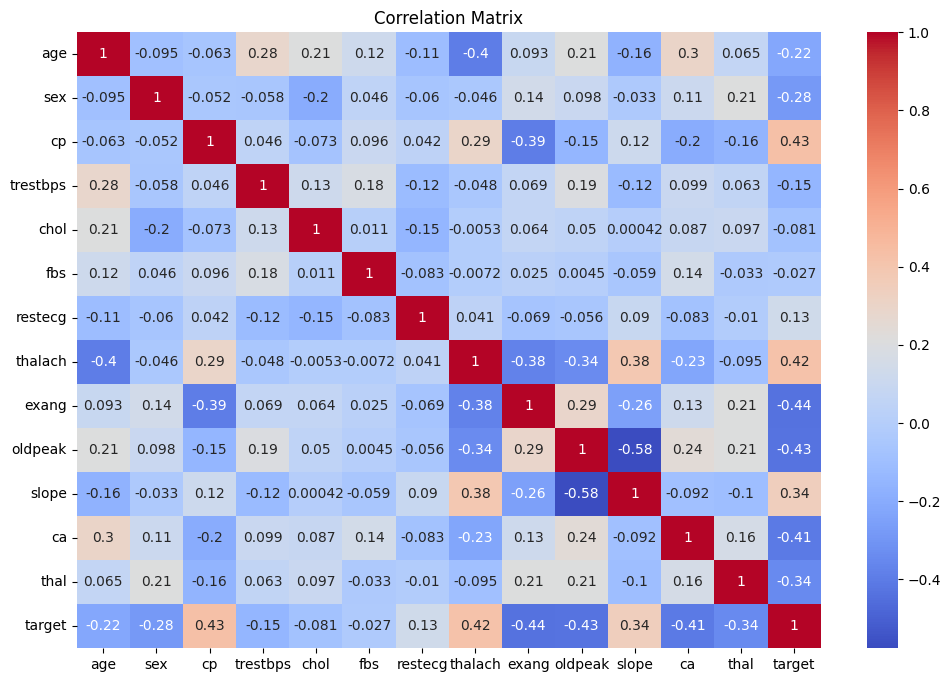

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Separate Features and Target

In [15]:
X = df.drop("target",axis=1)

y = df["target"]

Train Test Split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [17]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Training Model 1 (Logistic Regression)

In [18]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

Training Model 2 (KNN)

In [19]:
knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

pred_knn=knn.predict(X_test)

Training Model 3 (Random Forest)

In [20]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

Evaluation Function

In [21]:
def evaluate(y_test,pred):

    accuracy=accuracy_score(y_test,pred)

    precision=precision_score(y_test,pred)

    recall=recall_score(y_test,pred)

    f1=f1_score(y_test,pred)

    return accuracy,precision,recall,f1

In [22]:
lr_metrics=evaluate(y_test,pred_lr)

lr_metrics

(0.7704918032786885, 0.7027027027027027, 0.896551724137931, 0.7878787878787878)

In [23]:
knn_metrics=evaluate(y_test,pred_knn)

knn_metrics

(0.7377049180327869, 0.696969696969697, 0.7931034482758621, 0.7419354838709677)

In [24]:
rf_metrics=evaluate(y_test,pred_rf)

rf_metrics

(0.8360655737704918, 0.7878787878787878, 0.896551724137931, 0.8387096774193549)

In [25]:
comparison=pd.DataFrame({

'Model':['Logistic Regression','KNN','Random Forest'],

'Accuracy':[lr_metrics[0],knn_metrics[0],rf_metrics[0]],

'Precision':[lr_metrics[1],knn_metrics[1],rf_metrics[1]],

'Recall':[lr_metrics[2],knn_metrics[2],rf_metrics[2]],

'F1 Score':[lr_metrics[3],knn_metrics[3],rf_metrics[3]]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770492,0.702703,0.896552,0.787879
1,KNN,0.737705,0.696970,0.793103,0.741935
2,Random Forest,0.836066,0.787879,0.896552,0.838710


Confusion Matrix

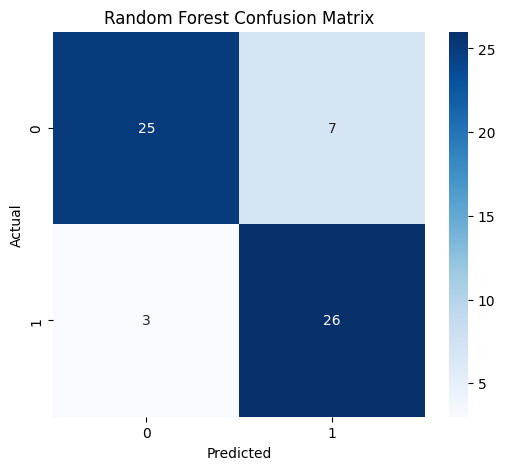

In [26]:
cm=confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

Classification Report

In [27]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



Feature Importance

In [28]:
importance=pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance=importance.sort_values(by='Importance',ascending=False)

importance

,Feature,Importance
7,thalach,0.138781
2,cp,0.131618
9,oldpeak,0.117095
12,thal,0.101598
11,ca,0.090493
0,age,0.090276
4,chol,0.075677
3,trestbps,0.071152
10,slope,0.055007
8,exang,0.050500


Feature Importance Graph

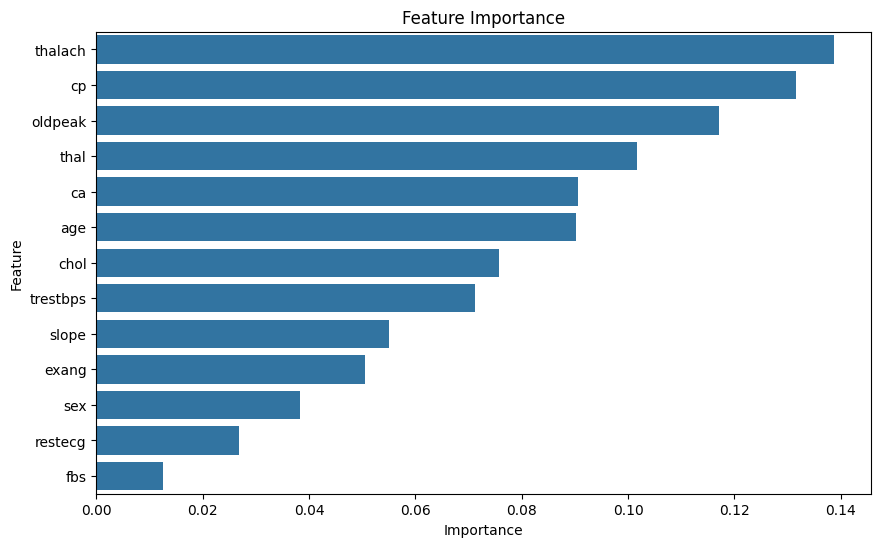

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(x='Importance',
            y='Feature',
            data=importance)

plt.title("Feature Importance")

plt.show()